In [ ]:
#Cancellation Patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'D:\202-2026bootcampproject\Python DataCleaning Output File.csv')

In [3]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['Invoice_Date_Only']=pd.to_datetime(df['Invoice_Date_Only'])
df['Week_Beginning']=pd.to_datetime(df['Week_Beginning'])

In [ ]:
#1: ISOLATE CANCELED ORDERS

In [7]:
Canceled = df[df['Order_Status'] == 'Cancelled'].copy()
Canceled['Revenue'] = Canceled['Quantity'] * Canceled['Price']

Canceled['Revenue'] = Canceled['Revenue'].abs()

In [ ]:
# 1: WHO CANCELS?

In [8]:
top_cancel_customers = Canceled.groupby('Customer ID')['Revenue'].sum().reset_index()
top_cancel_customers = top_cancel_customers.sort_values(by='Revenue', ascending=False).head(5)

print("--- Top 5 Customers with Highest Canceled Value ---")
print(top_cancel_customers)
print("\n")

--- Top 5 Customers with Highest Canceled Value ---
    Customer ID  Revenue
0             0  6996.30
38        14213   459.90
51        14911   301.84
67        15838   280.80
92        17340   267.12




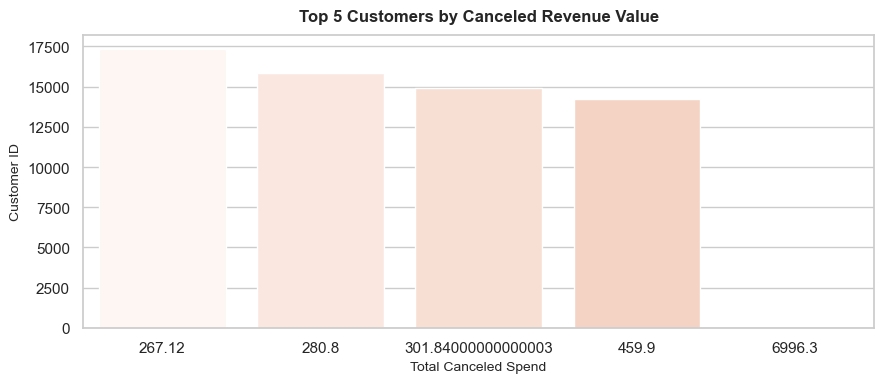

In [15]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=top_cancel_customers,
    x='Revenue',
    y='Customer ID',
    hue='Customer ID',     # Keeps seaborn happy and colorful
    palette='Reds_r',
    legend=False
)
plt.title('Top 5 Customers by Canceled Revenue Value', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Total Canceled Spend', fontsize=10)
plt.ylabel('Customer ID', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
#2: WHAT PRODUCTS?

In [11]:
Canceled['Abs_Quantity'] = Canceled['Quantity'].abs()

top_cancel_products = Canceled.groupby('Description')['Abs_Quantity'].sum().reset_index()
top_cancel_products.rename(columns={'Abs_Quantity': 'Quantity'}, inplace=True)
top_cancel_products = top_cancel_products.sort_values(by='Quantity', ascending=False).head(5)

print("--- Top 5 Most Frequently Canceled Products ---")
print(top_cancel_products)
print("\n")

--- Top 5 Most Frequently Canceled Products ---
                             Description  Quantity
105  Rotating Silver Angels T-Light Hldr      9369
24                Christmas Gingham Star       144
118    Smallfolkart Bauble Christmas Dec        96
36          Doormat Merry Christmas Red         50
8              Assorted Colours Silk Fan        48




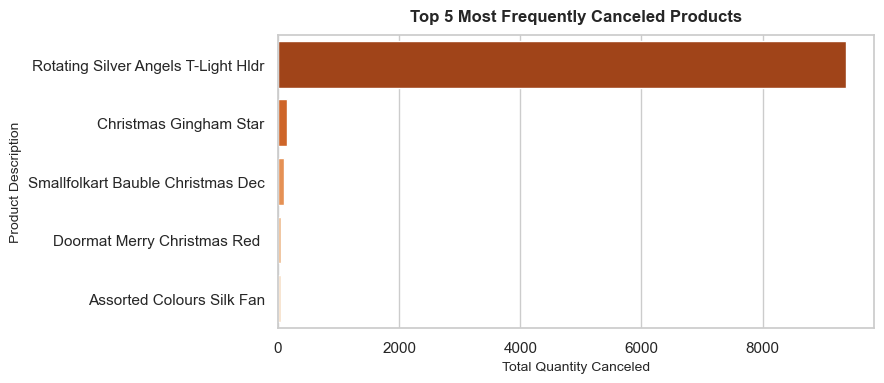

In [14]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=top_cancel_products,
    x='Quantity',
    y='Description',
    hue='Description',     # Avoids the palette warning
    palette='Oranges_r',
    legend=False
)
plt.title('Top 5 Most Frequently Canceled Products', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Total Quantity Canceled', fontsize=10)
plt.ylabel('Product Description', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
#3: WHEN DO THEY CANCEL?

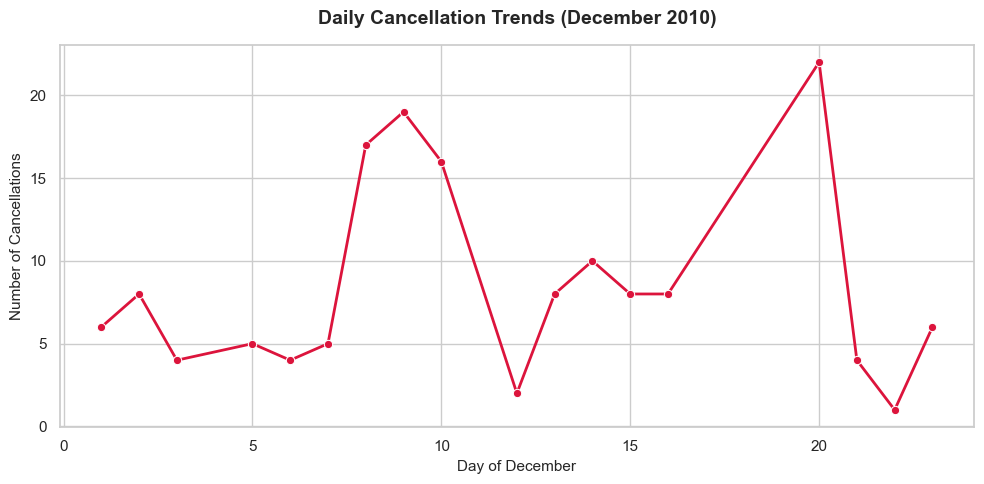

In [12]:
Canceled['Day_of_Month'] = Canceled['InvoiceDate'].dt.day

plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')

sns.lineplot(
    data=Canceled.groupby('Day_of_Month').size().reset_index(name='Total_Cancellations'),
    x='Day_of_Month',
    y='Total_Cancellations',
    marker='o',
    color='crimson',
    linewidth=2
)


plt.title('Daily Cancellation Trends (December 2010)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of December', fontsize=11)
plt.ylabel('Number of Cancellations', fontsize=11)

plt.tight_layout()
plt.show()